In [1]:
import sys
sys.path.append('..')

import numpy as np
import hmm
import emission_model
import matplotlib.pyplot as plt

# Test on synthetic HMM with Gaussian emissions


In [ ]:
mu_th    = [0.05,  -0.08,  0.00]
sigma_th = [0.008,  0.015,  0.025]
A_th = np.array([[0.9, 0.08, 0.02],
                  [0.03, 0.95, 0.02],
                  [0.05, 0.05, 0.90]])



def generate_gaussian_data(T=2000, seed=42, A= A_th, mu=mu_th, sigma=sigma_th):

    rng = np.random.default_rng(seed)
    # True params: 3 regimes (bull, bear, volatile)
    

    states, obs = [], []
    s = 0
    for _ in range(T):
        states.append(s)
        # Gaussian sample
        x = np.random.normal(mu[s], sigma[s])
        obs.append(x)
        s = rng.choice(3, p=A[s])
    return np.array(obs), np.array(states)

In [3]:
obs, states = generate_gaussian_data(T=20000)
obs=obs.reshape((1, obs.shape[0]))

(array([  1.,   1.,   0.,   0.,   2.,   0.,   1.,   1.,   0.,   1.,   3.,
          1.,   3.,   7.,   7.,   3.,   5.,   4.,   4.,  14.,   9.,   9.,
         10.,  17.,  16.,  17.,  23.,  16.,  33.,  22.,  27.,  41.,  32.,
         43.,  60.,  58.,  72.,  69.,  83.,  84.,  98., 104., 123., 123.,
        117., 135., 155., 163., 174., 174., 205., 196., 225., 203., 209.,
        234., 248., 242., 247., 255., 251., 270., 267., 273., 268., 272.,
        255., 283., 239., 288., 229., 263., 234., 233., 236., 231., 202.,
        197., 174., 163., 208., 152., 160., 159., 138., 103., 124.,  91.,
        100.,  88.,  80.,  98.,  63.,  43.,  60.,  61.,  47.,  49.,  38.,
         32.,  29.,  29.,  27.,  28.,  31.,  28.,  28.,  20.,  29.,  22.,
         19.,  24.,  19.,  20.,  21.,  21.,  24.,  24.,  17.,  19.,  27.,
         17.,  24.,  27.,  31.,  33.,  32.,  35.,  33.,  34.,  39.,  37.,
         41.,  38.,  45.,  52.,  43.,  42.,  37.,  39.,  41.,  42.,  46.,
         42.,  51.,  47.,  45.,  49., 

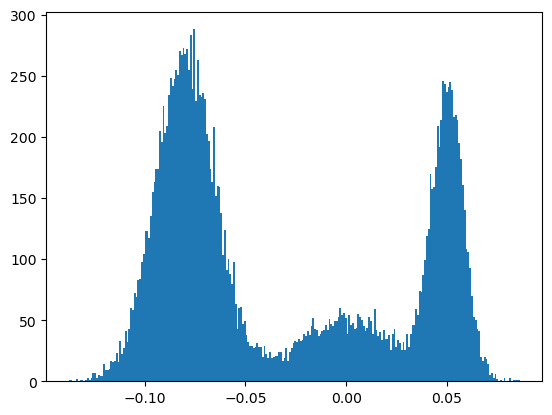

In [4]:
plt.hist(obs[0, :], bins=250)

In [5]:
from tqdm import tqdm
### Gaussian emissions
err_t = []
final_err = []
HMM_list = []
N_cycles = 10

for i in range(N_cycles):
    
    pi = np.random.rand((3))
    pi = pi/np.sum(pi)
    
    params = np.array([
    [np.random.uniform(-0.05, 0.05), np.random.uniform(0.0, 0.05)],  # state 0
    [np.random.uniform(-0.05, 0.05), np.random.uniform(0.0, 0.05)],  # state 1
    [np.random.uniform(-0.05, 0.05), np.random.uniform(0.0, 0.05)]  # state 2
    ])
    
    emission = emission_model.Gaussian_Emission(3, obs, params)
    HMM = hmm.Hmm(3, emission, pi, A=None, eps=1e-8)
    
    err_t.append(HMM.Baum_Welch(obs, N_max=35))
    final_err.append(err_t[i][-1])
    HMM_list.append(HMM)
    

############################################################################################################################################################################
Start learning: Baum-Welch expectation - maximization algorithm 
Iteration    1  |  -logL =       0.914633  |  -ΔL/L = 100.000000%
Iteration    2  |  -logL =      -2.047015  |  -ΔL/L = -323.807287%
Iteration    3  |  -logL =      -2.149420  |  -ΔL/L = 5.002636%
Iteration    4  |  -logL =      -2.258154  |  -ΔL/L = 5.058740%
Iteration    5  |  -logL =      -2.295828  |  -ΔL/L = 1.668354%
Iteration    6  |  -logL =      -2.324567  |  -ΔL/L = 1.251815%
Iteration    7  |  -logL =      -2.372524  |  -ΔL/L = 2.063023%
Iteration    8  |  -logL =      -2.445009  |  -ΔL/L = 3.055206%
Iteration    9  |  -logL =      -2.528484  |  -ΔL/L = 3.414086%
Iteration   10  |  -logL =      -2.567852  |  -ΔL/L = 1.556969%
Iteration   11  |  -logL =      -2.575198  |  -ΔL/L = 0.286107%
Iteration   12  |  -logL =      -2.576072  |  -ΔL/L =

In [ ]:
# choose the HMM with the lowest -logL
HMM = HMM_list[np.argmin(np.array(final_err))]

HMM.emission.gauss_params = HMM.emission.gauss_params[np.argsort(HMM.emission.gauss_params[:, 0]), :]
th_sort = np.argsort(np.array(mu_th))
mu_th = np.array(mu_th)[th_sort]
sigma_th = np.array(sigma_th)[th_sort]

print(r'Synthetic Gaussian generating processes ($\mu$, $\sigma$:) ')
print(' ')
print([(float(mu_th[i]), float(sigma_th[i])) for i in range(len(mu_th))])
print(' ')
print(r'Learned Gaussian generating processes: HMM.emission.gauss_params')
print(' ')
print([(float(np.round(HMM.emission.gauss_params[i, 0], 4)), (float(np.round(HMM.emission.gauss_params[i, 1], 4)))) for i in range(HMM.emission.gauss_params.shape[0])])


#print(r'Transition matrix generating synthetic data $A_{th}$ =' A_th)
#print(r'Best learned transition matrix $A_{hmm}$ = ', HMM.A)

Synthetic Gaussian generating processes ($\mu$, $\sigma$:) 
 
[(-0.08, 0.015), (0.0, 0.025), (0.05, 0.008)]
 
Learned Gaussian generating processes:HMM.emission.gauss_params
 
[(-0.08, 0.0149), (-0.0002, 0.025), (0.0502, 0.008)]


In [11]:
np.argsort(np.array(mu_th))

array([0, 1, 2])

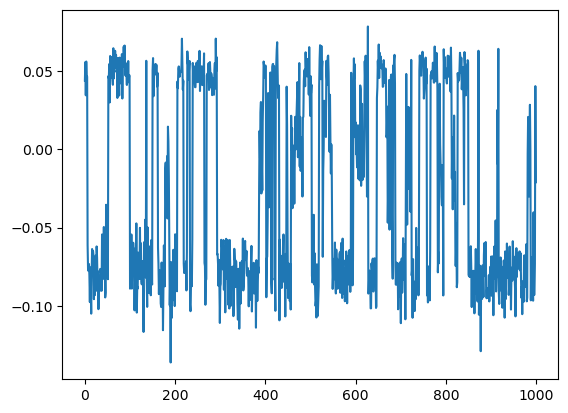

In [12]:
plt.plot(obs[0, :1000])